<a href="https://www.kaggle.com/code/sonawanelalitsunil/ipl-dataset-2008-2022-ml-100?scriptVersionId=231675488" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ipl-dataset-2008-2022/IPL Dataset 2008-2022.csv


## Title: IPL Dataset (2008-2022)

#### Description: This dataset contains match-wise details of the Indian Premier League (IPL) from 2008 to 2022, including team performances, player statistics, venues, and match outcomes. It is useful for cricket analytics, predictive modeling, and trend analysis.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/ipl-dataset-2008-2022/IPL Dataset 2008-2022.csv')

In [3]:
df.head()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals


In [4]:
df.tail()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
225949,335982,2,14,5,P Kumar,I Sharma,SB Joshi,legbyes,0,1,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore
225950,335982,2,14,6,SB Joshi,I Sharma,P Kumar,NaN,1,0,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore
225951,335982,2,14,7,P Kumar,I Sharma,SB Joshi,NaN,0,0,0,0,0,NaN,NaN,NaN,Royal Challengers Bangalore
225952,335982,2,15,1,SB Joshi,LR Shukla,P Kumar,wides,0,1,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore
225953,335982,2,15,2,SB Joshi,LR Shukla,P Kumar,NaN,0,0,0,0,1,SB Joshi,caught,BB McCullum,Royal Challengers Bangalore


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225954 entries, 0 to 225953
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   ID                 225954 non-null  int64 
 1   innings            225954 non-null  int64 
 2   overs              225954 non-null  int64 
 3   ballnumber         225954 non-null  int64 
 4   batter             225954 non-null  object
 5   bowler             225954 non-null  object
 6   non-striker        225954 non-null  object
 7   extra_type         12049 non-null   object
 8   batsman_run        225954 non-null  int64 
 9   extras_run         225954 non-null  int64 
 10  total_run          225954 non-null  int64 
 11  non_boundary       225954 non-null  int64 
 12  isWicketDelivery   225954 non-null  int64 
 13  player_out         11151 non-null   object
 14  kind               11151 non-null   object
 15  fielders_involved  7988 non-null    object
 16  BattingTeam        2

In [6]:
df.describe()

,ID,innings,overs,ballnumber,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery
count,2.259540e+05,225954.000000,225954.000000,225954.000000,225954.000000,225954.000000,225954.00000,225954.000000,225954.000000
mean,8.320470e+05,1.483868,9.185679,3.619750,1.243523,0.066907,1.31043,0.000093,0.049351
std,3.379542e+05,0.503104,5.681797,1.810633,1.618166,0.341470,1.60605,0.009640,0.216600
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,5.012620e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,8.297370e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.00000,0.000000,0.000000
75%,1.178395e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.00000,0.000000,0.000000
max,1.312200e+06,6.000000,19.000000,10.000000,6.000000,7.000000,7.00000,1.000000,1.000000


In [7]:
df.isnull().sum()

ID                        0
innings                   0
overs                     0
ballnumber                0
batter                    0
bowler                    0
non-striker               0
extra_type           213905
batsman_run               0
extras_run                0
total_run                 0
non_boundary              0
isWicketDelivery          0
player_out           214803
kind                 214803
fielders_involved    217966
BattingTeam               0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(225954, 17)

In [10]:
df.dtypes

ID                    int64
innings               int64
overs                 int64
ballnumber            int64
batter               object
bowler               object
non-striker          object
extra_type           object
batsman_run           int64
extras_run            int64
total_run             int64
non_boundary          int64
isWicketDelivery      int64
player_out           object
kind                 object
fielders_involved    object
BattingTeam          object
dtype: object

In [11]:
df.columns

Index(['ID', 'innings', 'overs', 'ballnumber', 'batter', 'bowler',
       'non-striker', 'extra_type', 'batsman_run', 'extras_run', 'total_run',
       'non_boundary', 'isWicketDelivery', 'player_out', 'kind',
       'fielders_involved', 'BattingTeam'],
      dtype='object')

## Data visualizations

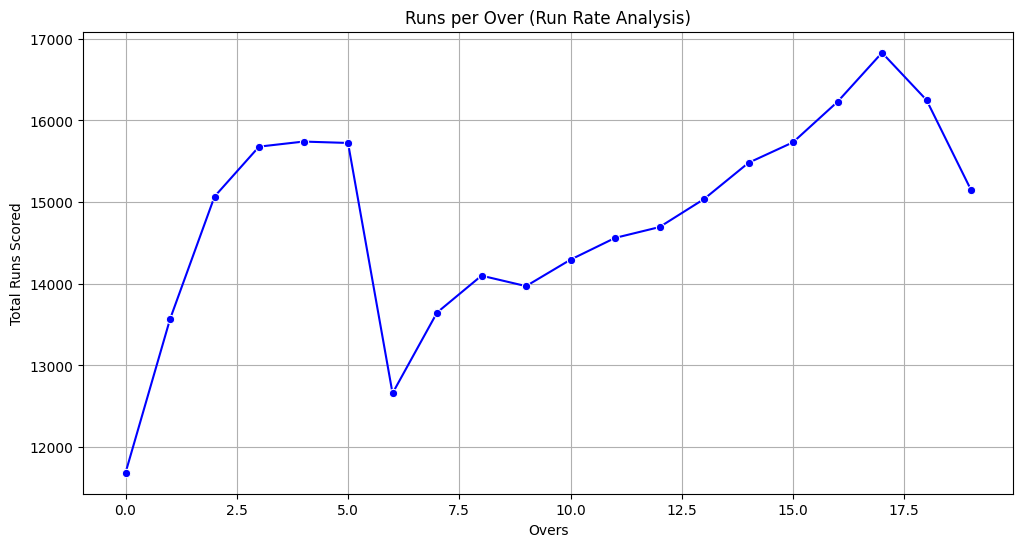

In [12]:
# 1. Runs per over (Run Rate Analysis)
plt.figure(figsize=(12, 6))
run_rate = df.groupby('overs')['total_run'].sum()
sns.lineplot(x=run_rate.index, y=run_rate.values, marker='o', color='blue')
plt.xlabel('Overs')
plt.ylabel('Total Runs Scored')
plt.title('Runs per Over (Run Rate Analysis)')
plt.grid()
plt.show()

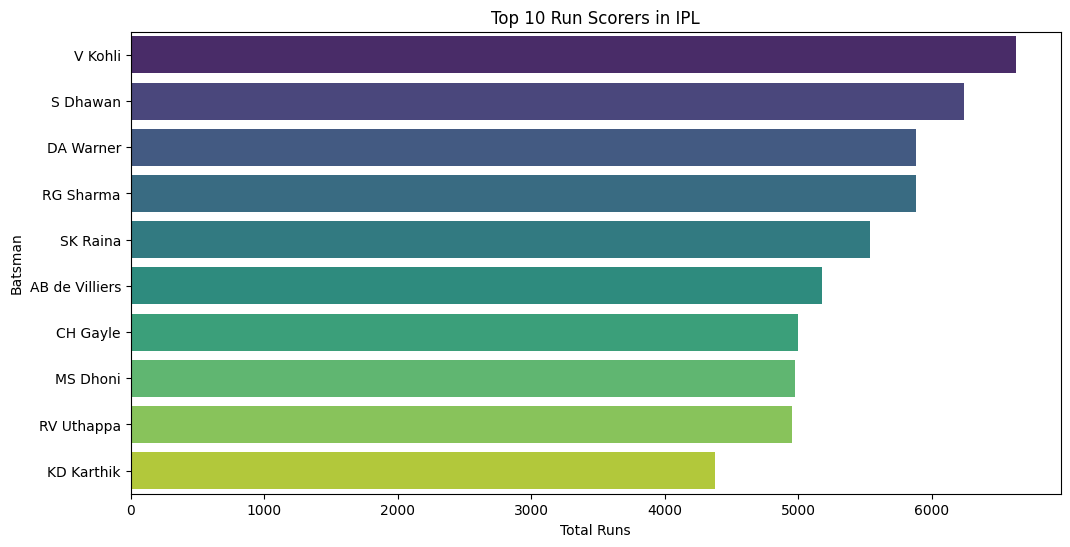

In [13]:
# 2. Top Run Scorers
plt.figure(figsize=(12, 6))
top_scorers = df.groupby('batter')['batsman_run'].sum().nlargest(10)
sns.barplot(x=top_scorers.values, y=top_scorers.index, palette='viridis')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.title('Top 10 Run Scorers in IPL')
plt.show()


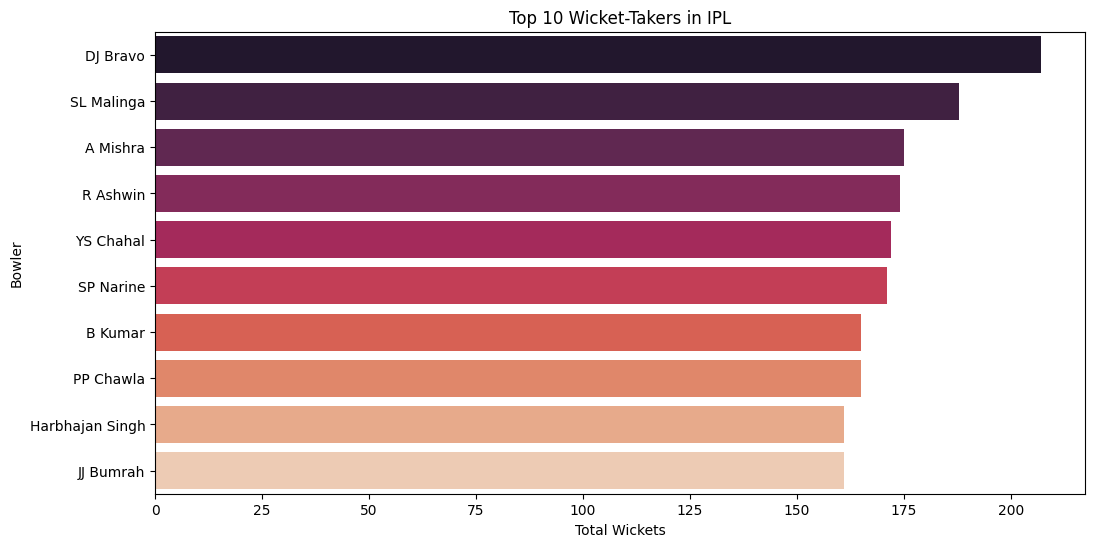

In [14]:
# 3. Top Wicket-Takers
plt.figure(figsize=(12, 6))
wickets = df[df['isWicketDelivery'] == 1].groupby('bowler').size().nlargest(10)
sns.barplot(x=wickets.values, y=wickets.index, palette='rocket')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.title('Top 10 Wicket-Takers in IPL')
plt.show()


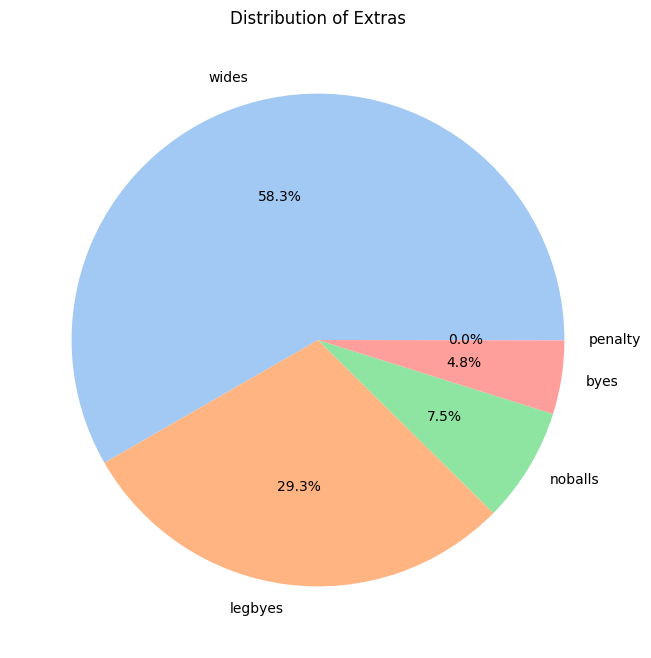

In [15]:
# 4. Distribution of Extras
plt.figure(figsize=(8, 8))
extra_types = df['extra_type'].value_counts()
plt.pie(extra_types, labels=extra_types.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Distribution of Extras')
plt.show()

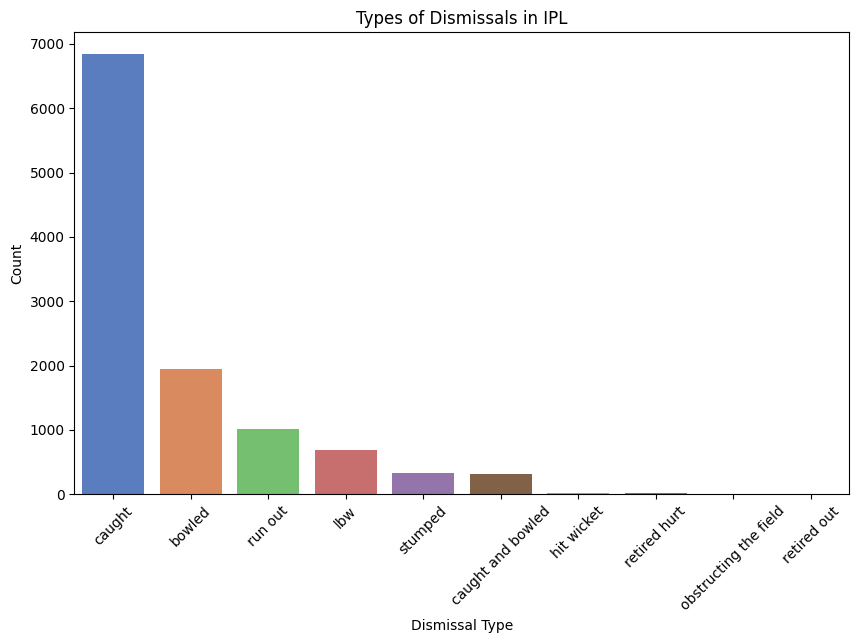

In [16]:
# 5. Dismissal Types
plt.figure(figsize=(10, 6))
dismissal_types = df['kind'].value_counts()
sns.barplot(x=dismissal_types.index, y=dismissal_types.values, palette='muted')
plt.xlabel('Dismissal Type')
plt.ylabel('Count')
plt.title('Types of Dismissals in IPL')
plt.xticks(rotation=45)
plt.show()

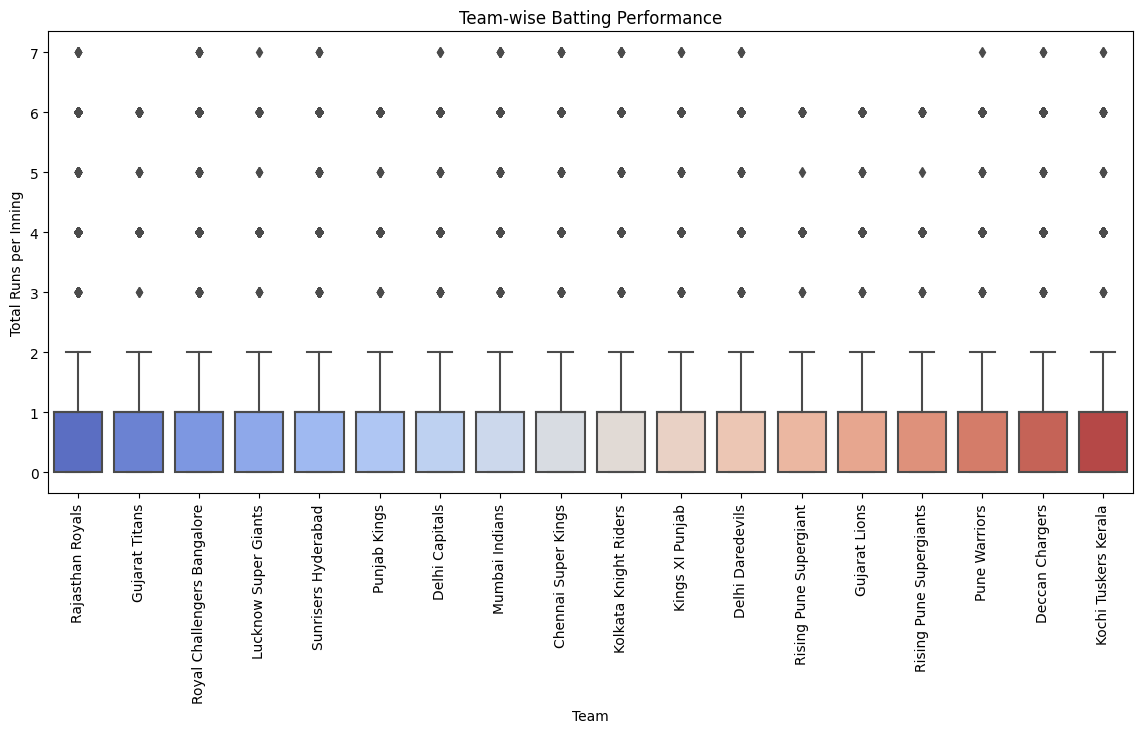

In [17]:
# 6. Batting Team Performance
plt.figure(figsize=(14, 6))
sns.boxplot(x='BattingTeam', y='total_run', data=df, palette='coolwarm')
plt.xticks(rotation=90)
plt.xlabel('Team')
plt.ylabel('Total Runs per Inning')
plt.title('Team-wise Batting Performance')
plt.show()

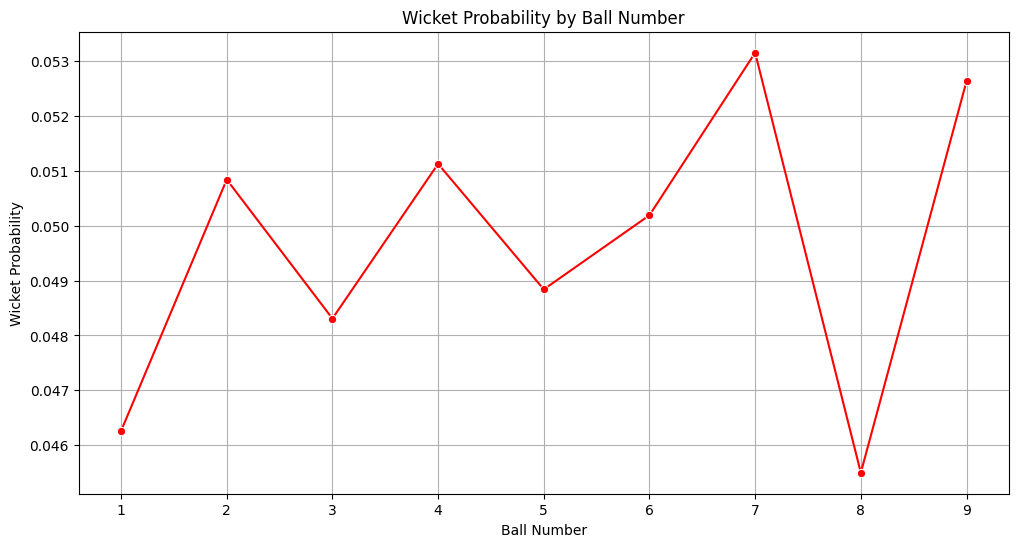

In [18]:
# 7. Over-wise Wicket Probability
plt.figure(figsize=(12, 6))
wicket_probability = df[df['isWicketDelivery'] == 1].groupby('ballnumber').size() / df.groupby('ballnumber').size()
sns.lineplot(x=wicket_probability.index, y=wicket_probability.values, marker='o', color='red')
plt.xlabel('Ball Number')
plt.ylabel('Wicket Probability')
plt.title('Wicket Probability by Ball Number')
plt.grid()
plt.show()

## Predictive modeling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB


In [20]:
# Label Encoding for categorical columns
label_encoders = {}
categorical_columns = ['batter', 'bowler', 'non-striker', 'extra_type', 'player_out', 'kind', 'fielders_involved', 'BattingTeam']

In [21]:
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [22]:
# Define features and target
X = df.drop(columns=['isWicketDelivery'])  # Features
y = df['isWicketDelivery']  # Target

In [23]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [24]:
# Function to train and evaluate multiple models
def train_and_evaluate(model, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred) * 100
    cm = confusion_matrix(y_test, y_pred)
    print(f'\nAccuracy for {model_name}: {accuracy:.2f}%')
    print(f'\nConfusion Matrix for {model_name}:')
    print(cm)
    print(f'\nClassification Report for {model_name}:')
    print(classification_report(y_test, y_pred))
    # Plot confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()




In [25]:
# Applying Machine Learning Algorithms
models = {
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}


Accuracy for Random Forest: 100.00%

Confusion Matrix for Random Forest:
[[42945     0]
 [    0  2246]]

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42945
           1       1.00      1.00      1.00      2246

    accuracy                           1.00     45191
   macro avg       1.00      1.00      1.00     45191
weighted avg       1.00      1.00      1.00     45191



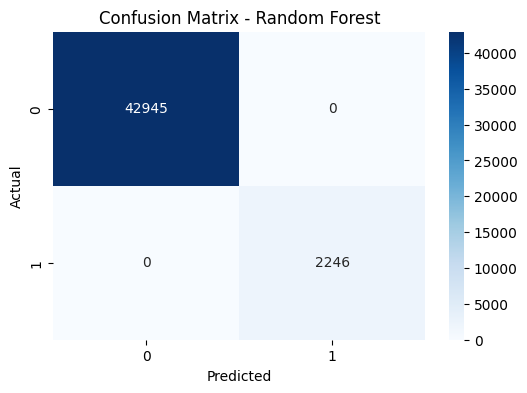


Accuracy for SVM: 95.03%

Confusion Matrix for SVM:
[[42945     0]
 [ 2246     0]]

Classification Report for SVM:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     42945
           1       0.00      0.00      0.00      2246

    accuracy                           0.95     45191
   macro avg       0.48      0.50      0.49     45191
weighted avg       0.90      0.95      0.93     45191



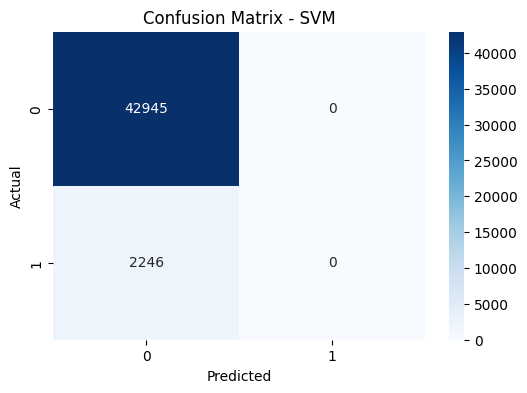


Accuracy for Decision Tree: 100.00%

Confusion Matrix for Decision Tree:
[[42945     0]
 [    0  2246]]

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42945
           1       1.00      1.00      1.00      2246

    accuracy                           1.00     45191
   macro avg       1.00      1.00      1.00     45191
weighted avg       1.00      1.00      1.00     45191



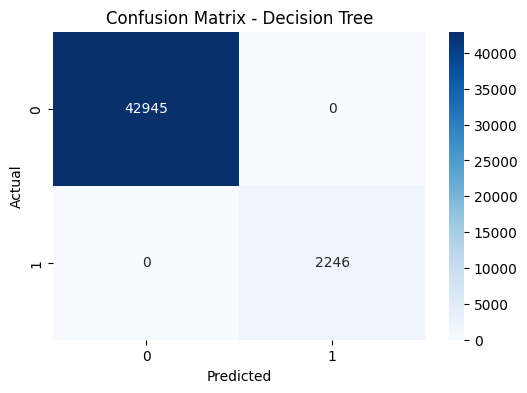


Accuracy for KNN: 99.64%

Confusion Matrix for KNN:
[[42945     0]
 [  163  2083]]

Classification Report for KNN:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42945
           1       1.00      0.93      0.96      2246

    accuracy                           1.00     45191
   macro avg       1.00      0.96      0.98     45191
weighted avg       1.00      1.00      1.00     45191



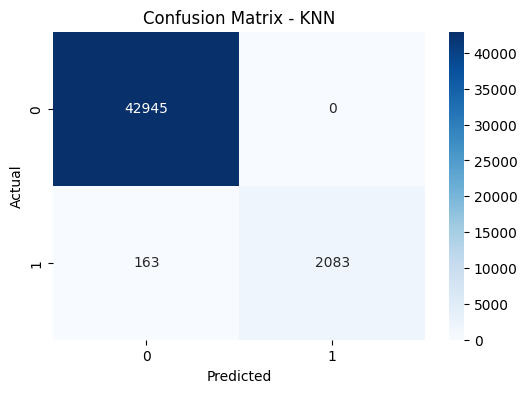


Accuracy for Naive Bayes: 99.87%

Confusion Matrix for Naive Bayes:
[[42945     0]
 [   57  2189]]

Classification Report for Naive Bayes:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42945
           1       1.00      0.97      0.99      2246

    accuracy                           1.00     45191
   macro avg       1.00      0.99      0.99     45191
weighted avg       1.00      1.00      1.00     45191



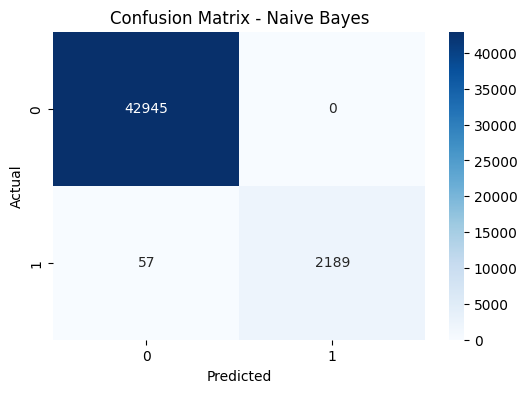

In [26]:
for model_name, model in models.items():
    train_and_evaluate(model, model_name)

## Thank you..pls upvote!!!!